# Imports

In [1]:
import os
import sys
import subprocess
import pathlib
import shutil
import random
from shutil import copy2
from pathlib import Path
from PIL import Image
import statistics

REPO_URL = "https://github.com/willloe/MSML640_Group10.git"
REPO_DIR = Path("/content/MSML640_Group10")
BRANCH = "will/dev"

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    print("Repo already present; syncing to latest")
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)

subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin", BRANCH], check=True)
subprocess.run(["git", "-C", str(REPO_DIR), "checkout", BRANCH], check=True)
subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)

print("Current repo:", REPO_DIR)

SRC = REPO_DIR / "packages" / "diffusion" / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

SCRIPTS_DIR = REPO_DIR / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import torch
import importlib

print("CUDA available:", torch.cuda.is_available())
print("CUDA device name:",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

diffusers = importlib.import_module("diffusers")
print("diffusers version:", getattr(diffusers, "__version__", "unknown"))

Current repo: /content/MSML640_Group10
CUDA available: True
CUDA device name: NVIDIA L4
diffusers version: 0.35.2


In [2]:
from data import get_dataloaders
from lora import build_manifest
from lora.lora_train import main as lora_train_main
from run_eval_ab import main as run_eval_ab_main
from synthetic import sample_condition_batch
from preview_slide import render_slide_with_text
from infer import generate_and_mask
from sdxl import prompt_from_palette, add_slidesafe_token
from evaluate import layout_uniformity_score, wcag_pass_rate, wcag_pass_rate_safe_zone
from style_labeling import build_style_manifest

from google.colab import drive
from pathlib import Path
from diffusers import ControlNetModel, StableDiffusionXLControlNetPipeline

drive.mount("/content/drive", force_remount=True)

DRIVE_ROOT = Path("/content/drive/MyDrive/MSML640/")
DRIVE_DATA_DIR = DRIVE_ROOT / "data"
DRIVE_OUTPUTS_DIR = DRIVE_ROOT / "outputs"

SYN_DIR = DRIVE_DATA_DIR / "synthetic_dataset"
IMG_DIR = DRIVE_DATA_DIR / "images_flattened"

print("Drive data dir:", DRIVE_DATA_DIR, "exists:", DRIVE_DATA_DIR.exists())
print(" synthetic_dataset dir:", SYN_DIR, "exists:", SYN_DIR.exists())
print(" images_flattened dir:", IMG_DIR, "exists:", IMG_DIR.exists())

if SYN_DIR.exists():
    print(" synthetic_dataset contents:", [p.name for p in SYN_DIR.iterdir()])
if (SYN_DIR / "train").exists():
    SYN_TRAIN_DIR = SYN_DIR / "train"
else:
    SYN_TRAIN_DIR = SYN_DIR

print(" Using layout masks from:", SYN_TRAIN_DIR)

Mounted at /content/drive
Drive data dir: /content/drive/MyDrive/MSML640/data exists: True
 synthetic_dataset dir: /content/drive/MyDrive/MSML640/data/synthetic_dataset exists: True
 images_flattened dir: /content/drive/MyDrive/MSML640/data/images_flattened exists: True
 synthetic_dataset contents: ['train', 'test']
 Using layout masks from: /content/drive/MyDrive/MSML640/data/synthetic_dataset/train


In [3]:
DEMO_CFG = dict(
    width=1024,
    height=576,
    steps=30,
    guidance=4.5,
)

METRIC_CFG = dict(
    width=1024,
    height=768,
    steps=25,
    guidance=3.5,
)

EVAL_NUM_SAMPLES = 4
EVAL_SEED_START = 655

CKPT_GEN_SEEDS = [42, 1234]

print("DEMO_CFG:", DEMO_CFG)
print("METRIC_CFG:", METRIC_CFG)


DEMO_CFG: {'width': 1024, 'height': 576, 'steps': 30, 'guidance': 4.5}
METRIC_CFG: {'width': 1024, 'height': 768, 'steps': 25, 'guidance': 3.5}


In [4]:
LORA_IMAGES_DIR = IMG_DIR
LOCAL_OUTPUTS_DIR = REPO_DIR / "outputs"
RUN_DIR = LOCAL_OUTPUTS_DIR / "lora" / "runs" / "exp01"
MASTER_CAP_JSONL = DRIVE_ROOT / "data" / "captions_master.jsonl"

LOCAL_LORA_DIR = RUN_DIR / "final_lora"
LOCAL_LORA_FILE = LOCAL_LORA_DIR / "unet_lora_peft.pt"

DRIVE_RUN_DIR = DRIVE_ROOT / "outputs" / "lora" / "runs" / "exp01"
DRIVE_LORA_DIR = DRIVE_RUN_DIR / "final_lora"
DRIVE_LORA_FILE = DRIVE_LORA_DIR / "unet_lora_peft.pt"

def sync_dir(src: Path, dst: Path) -> None:
    src = Path(src)
    dst = Path(dst)

    if not src.exists():
        print(f" Source dir does not exist, skipping: {src}")
        return

    dst.mkdir(parents=True, exist_ok=True)

    for item in src.rglob("*"):
        rel = item.relative_to(src)
        out_path = dst / rel

        if item.is_dir():
            out_path.mkdir(parents=True, exist_ok=True)
        elif item.is_file():
            out_path.parent.mkdir(parents=True, exist_ok=True)
            copy2(item, out_path)

    print(f" Synced {src} -> {dst}")

if DRIVE_RUN_DIR.exists() and not RUN_DIR.exists():
    print("\nSyncing entire run dir from drive to local...")
    sync_dir(DRIVE_RUN_DIR, RUN_DIR)

MANIFESTS_DIR = RUN_DIR / "manifests"
MANIFESTS_DIR.mkdir(parents=True, exist_ok=True)


Syncing entire run dir from drive to local...
 Synced /content/drive/MyDrive/MSML640/outputs/lora/runs/exp01 -> /content/MSML640_Group10/outputs/lora/runs/exp01


# Pre-training (Labelling Dataset)

In [5]:
CAP_JSONL = MANIFESTS_DIR / "captions.jsonl"
CAP_JSONL.parent.mkdir(parents=True, exist_ok=True)

if not CAP_JSONL.exists():
    build_style_manifest(LORA_IMAGES_DIR, CAP_JSONL, overwrite=False)
    print("Built caption manifest:", CAP_JSONL)
else:
    print("Using existing caption manifest:", CAP_JSONL)

Using existing caption manifest: /content/MSML640_Group10/outputs/lora/runs/exp01/manifests/captions.jsonl


# Training

In [6]:
if LOCAL_LORA_FILE.exists():
    print("\nLoRA weights already found locally, skipping training.")
    print("Local LoRA dir:", LOCAL_LORA_DIR)
else:
    print("\nTraining SDXL using abstract background style.")
    print("Images:", LORA_IMAGES_DIR)
    print("Run dir:", RUN_DIR)
    print("Manifest:", CAP_JSONL)

    train_argv = [
        "--images_dir", str(LORA_IMAGES_DIR),
        "--model_id", "stabilityai/stable-diffusion-xl-base-1.0",
        "--output_dir", str(RUN_DIR),
        "--resolution", "512",
        "--rank", "16",
        "--lr", "1e-4",
        "--batch_size", "4",
        "--gradient_accumulation_steps", "2",
        "--max_train_steps", "1500",
        "--checkpoint_steps", "250",
        "--seed", "42",
        "--train_jsonl", str(CAP_JSONL),
        "--layout-preproc",
        "--layout-mask-dir", str(SYN_TRAIN_DIR),
        "--layout-preproc-alpha", "0.8",
    ]

    ret = lora_train_main(train_argv)
    print("\nLoRA training finished with code:", ret)

    if not LOCAL_LORA_FILE.exists():
        print("Expected LoRA file not found at", LOCAL_LORA_FILE)
    else:
        DRIVE_LORA_DIR.mkdir(parents=True, exist_ok=True)
        sync_dir(LOCAL_OUTPUTS_DIR, DRIVE_OUTPUTS_DIR)

FINAL_LORA_DIR = LOCAL_LORA_DIR

print("final_lora local exists:", LOCAL_LORA_FILE.exists())
print("final_lora on Drive exists:", DRIVE_LORA_FILE.exists())
if LOCAL_LORA_FILE.exists():
    print("Local LoRA files:", list(LOCAL_LORA_DIR.glob("*.pt")))
else:
    print("No final_lora folder found locally")


LoRA weights already found locally, skipping training.
Local LoRA dir: /content/MSML640_Group10/outputs/lora/runs/exp01/final_lora
final_lora local exists: True
final_lora on Drive exists: True
Local LoRA files: [PosixPath('/content/MSML640_Group10/outputs/lora/runs/exp01/final_lora/unet_lora_peft.pt')]


# Inference

In [7]:
AB_OUT = REPO_DIR / "outputs" / "lora_ab"
AB_OUT.mkdir(parents=True, exist_ok=True)

width = DEMO_CFG["width"]
height = DEMO_CFG["height"]
steps = DEMO_CFG["steps"]
guidance = DEMO_CFG["guidance"]
SEEDS = [655]

print("\nCreating synthetic slide layouts and running base vs LoRA (all presets).")
print(f"Size: {width}x{height}, steps={steps}, guidance={guidance}")
print("Output folder:", AB_OUT)

for seed in SEEDS:
    print(f"\nSEED {seed}")
    samples = sample_condition_batch(
        n=1,
        canvas_size=(height, width),
        seed=seed,
    )

    print(f"Sampled {len(samples)} layouts.")

    presets = ["default", "academic", "noisy", "gradient", "photo"]

    lora_path_dir = str(FINAL_LORA_DIR) if FINAL_LORA_DIR.exists() else None
    if not lora_path_dir:
        print("final_lora dir not found")
    print(lora_path_dir)

    for layout_idx, s in enumerate(samples):
        print(f"\nLayout #{layout_idx}")
        print(
            "Control map shape:",
            None if s.get("control_map") is None else s["control_map"].shape,
        )
        print("Safe zone type:", type(s.get("safe_zone")))

        for preset in presets:
            print(f"\nLayout {layout_idx}, prompt preset: {preset}")
            prompt = prompt_from_palette(s["palette"], preset=preset)
            print("Prompt:", prompt)

            base_common = dict(
                prompt=prompt,
                palette=s["palette"],
                layout=s["layout"],
                safe_zone=s.get("safe_zone"),
                control_map=s.get("control_map"),
                model_id="stabilityai/stable-diffusion-xl-base-1.0",
                steps=steps,
                guidance=guidance,
                width=width,
                height=height,
                seed=seed,
                out_dir=str(AB_OUT),
                apply_safe_mask=False,
            )

            base_name = f"ab_layout{layout_idx}_{preset}_seed{seed}_base.png"
            lora_name = f"ab_layout{layout_idx}_{preset}_seed{seed}_lora.png"

            print("Generating base SDXL image (no LoRA)")
            base_path = generate_and_mask(
                lora_path=None,
                out_name=base_name,
                **base_common,
            )
            print("  Base image:", base_path)

            lora_common = {
                **base_common,
                "use_controlnet": True,
                "control_from": "safe",
                "controlnet_model_id": "diffusers/controlnet-canny-sdxl-1.0",
                "control_strength": 0.7,
            }

            print("Generating LoRA-tuned image")
            lora_path = generate_and_mask(
                lora_path=lora_path_dir,
                out_name=lora_name,
                **lora_common,
            )
            print("  LoRA image:", lora_path)

DRIVE_OUT = DRIVE_ROOT / "outputs" / "lora_ab"
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

sync_dir(LOCAL_OUTPUTS_DIR, DRIVE_OUTPUTS_DIR)
print("\nAll done. Check these files in:", AB_OUT)



Creating synthetic slide layouts and running base vs LoRA (all presets).
Size: 1024x576, steps=30, guidance=4.5
Output folder: /content/MSML640_Group10/outputs/lora_ab

SEED 655
Sampled 1 layouts.
/content/MSML640_Group10/outputs/lora/runs/exp01/final_lora

Layout #0
Control map shape: torch.Size([4, 576, 1024])
Safe zone type: <class 'torch.Tensor'>

Layout 0, prompt preset: default
Prompt: slidesafe single minimal professional presentation slide background, soft gradients, large clean content area, low contrast, no text, no logos, no collage, no grid, primary color #126092, secondary color #000867, accent color #E50DA7, subtle texture
Generating base SDXL image (no LoRA)
Prompt: slidesafe single minimal professional presentation slide background, soft gradients, large clean content area, low contrast, no text, no logos, no collage, no grid, primary color #126092, secondary color #000867, accent color #E50DA7, subtle texture


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

...

  Base image: /content/MSML640_Group10/outputs/lora_ab/ab_layout0_photo_seed655_base.png
Generating LoRA-tuned image
Prompt: slidesafe photographic background with shallow depth of field, soft bokeh and light leaks, muted colors, subject off-center, large negative space, primary color #126092, secondary color #000867, accent color #E50DA7, subtle texture
Using ControlNet: True (diffusers/controlnet-canny-sdxl-1.0), strength=0.7
ControlNet mode: safe
control_map dtype/shape: (torch.float32, torch.Size([4, 576, 1024]))


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading PEFT LoRA for ControlNet from /content/MSML640_Group10/outputs/lora/runs/exp01/final_lora/unet_lora_peft.pt
[LoRA] Detected rank=16 from lora_config.json
[LoRA] missing keys (subset): []


  0%|          | 0/30 [00:00<?, ?it/s]

  LoRA image: /content/MSML640_Group10/outputs/lora_ab/ab_layout0_photo_seed655_lora.png
 Synced /content/MSML640_Group10/outputs -> /content/drive/MyDrive/MSML640/outputs

All done. Check these files in: /content/MSML640_Group10/outputs/lora_ab


Showing comparisons from: /content/MSML640_Group10/outputs/lora_ab
Seeds: [655]
Presets: ['default', 'academic', 'noisy', 'gradient', 'photo']

SEED 655
Layout 0 for seed 655


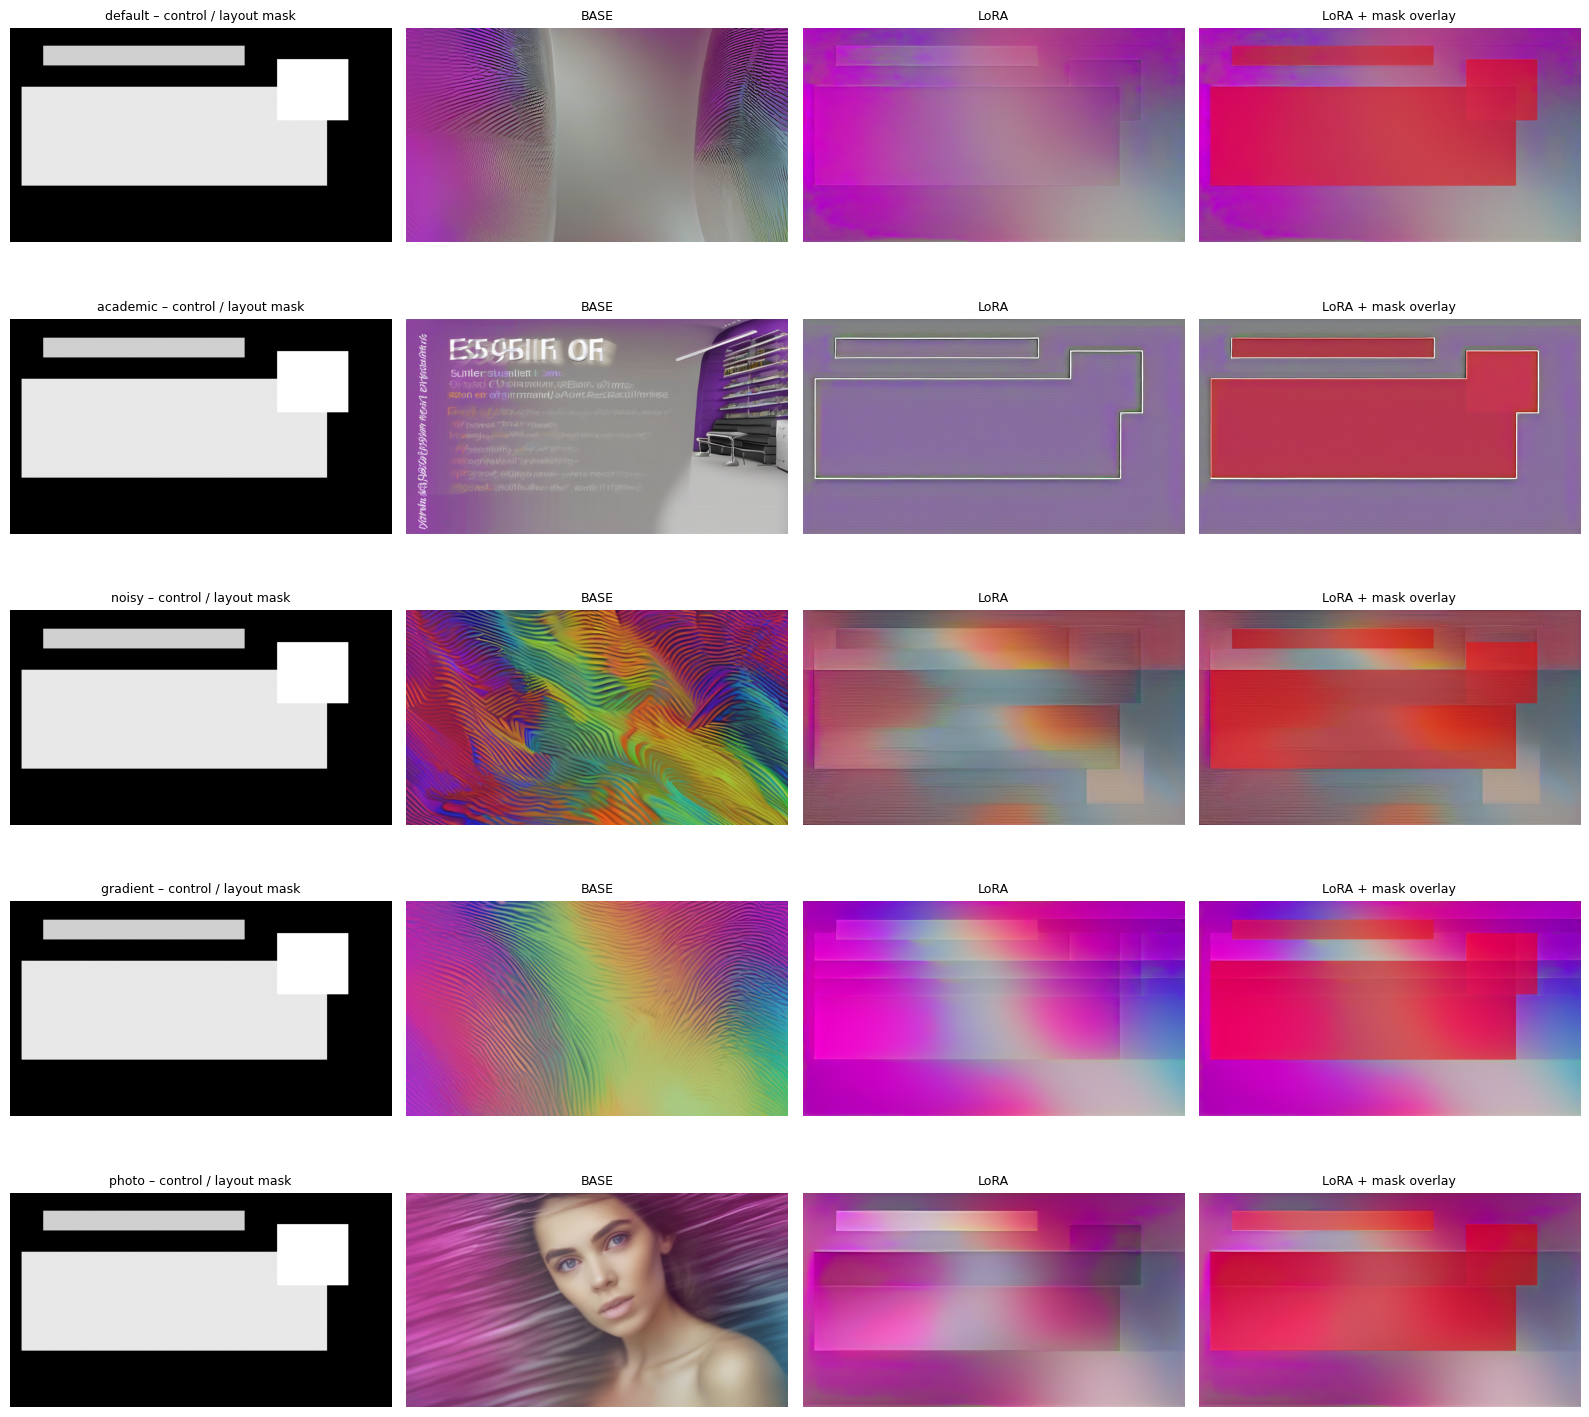

In [8]:
import numpy as np
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

gallery_dir = AB_OUT
width  = DEMO_CFG["width"]
height = DEMO_CFG["height"]
presets = ["default", "academic", "noisy", "gradient", "photo"]

print("Showing comparisons from:", gallery_dir)
print("Seeds:", SEEDS)
print("Presets:", presets)


def control_to_mask_np(sample):
    ctrl = sample.get("control_map")
    if ctrl is None or not isinstance(ctrl, torch.Tensor):
        return None

    cm = ctrl.detach().cpu().float()
    if cm.ndim == 3:
        cm = cm.mean(0)
    elif cm.ndim != 2:
        return None

    cm = cm - cm.min()
    if cm.max() > 0:
        cm = cm / cm.max()
    return cm.numpy()


for seed in SEEDS:
    print(f"\nSEED {seed}")

    samples = sample_condition_batch(
        n=1,
        canvas_size=(height, width),
        seed=seed,
    )

    for layout_idx, sample in enumerate(samples):
        print(f"Layout {layout_idx} for seed {seed}")
        mask_np = control_to_mask_np(sample)

        n_rows = len(presets)
        fig, axes = plt.subplots(
            n_rows, 4,
            figsize=(16, 3 * n_rows),
            squeeze=False,
        )

        for row_idx, preset in enumerate(presets):
            base_name = f"ab_layout{layout_idx}_{preset}_seed{seed}_base.png"
            lora_name = f"ab_layout{layout_idx}_{preset}_seed{seed}_lora.png"

            base_path = gallery_dir / base_name
            lora_path = gallery_dir / lora_name

            base_img = Image.open(base_path) if base_path.exists() else None
            lora_img = Image.open(lora_path) if lora_path.exists() else None

            ax_mask, ax_base, ax_lora, ax_overlay = axes[row_idx]

            ax_mask.axis("off")
            if mask_np is not None:
                ax_mask.imshow(mask_np, cmap="gray")
                ax_mask.set_title(
                    f"{preset} – control / layout mask",
                    fontsize=9,
                )
            else:
                ax_mask.text(
                    0.5, 0.5, "No control_map",
                    ha="center", va="center", fontsize=10,
                )

            ax_base.axis("off")
            if base_img is not None:
                ax_base.imshow(base_img)
                ax_base.set_title("BASE", fontsize=9)
            else:
                ax_base.text(
                    0.5, 0.5, "Base missing",
                    ha="center", va="center", fontsize=10,
                )

            ax_lora.axis("off")
            if lora_img is not None:
                ax_lora.imshow(lora_img)
                ax_lora.set_title("LoRA", fontsize=9)
            else:
                ax_lora.text(
                    0.5, 0.5, "LoRA missing",
                    ha="center", va="center", fontsize=10,
                )

            ax_overlay.axis("off")
            if lora_img is not None and mask_np is not None:
                lora_np = np.array(lora_img).astype("float32") / 255.0

                mask_rgb = np.stack(
                    [mask_np, np.zeros_like(mask_np), np.zeros_like(mask_np)],
                    axis=-1,
                )

                alpha = (mask_np > 0.1).astype("float32") * 0.5
                alpha = alpha[..., None]

                overlay_np = lora_np * (1.0 - alpha) + mask_rgb * alpha

                ax_overlay.imshow(overlay_np)
                ax_overlay.set_title("LoRA + mask overlay", fontsize=9)
            else:
                ax_overlay.text(
                    0.5, 0.5, "No overlay",
                    ha="center", va="center", fontsize=10,
                )

        plt.tight_layout()
        plt.show()


# Evaluation

In [9]:
from pathlib import Path
from PIL import Image
import statistics
import re
from collections import defaultdict

EVAL_DIR = DRIVE_ROOT / "outputs" / "lora_ab"

width  = DEMO_CFG["width"]
height = DEMO_CFG["height"]

print("Reading A/B images from:", EVAL_DIR)
pattern = re.compile(
    r"ab_layout(\d+)_(.+?)_seed(\d+)_(base|lora)\.png$"
)

pairs = defaultdict(dict)
seen_seeds = set()
seen_presets = set()

for p in Path(EVAL_DIR).glob("ab_layout*_seed*_*png"):
    m = pattern.match(p.name)
    if not m:
        continue
    layout_idx_str, preset, seed_str, kind = m.groups()
    seed = int(seed_str)
    layout_idx = int(layout_idx_str)

    key = (seed, layout_idx, preset)
    pairs[key][kind] = p

    seen_seeds.add(seed)
    seen_presets.add(preset)

print("Discovered seeds:", sorted(seen_seeds))
print("Discovered presets:", sorted(seen_presets))

safe_stds_base = []
safe_stds_lora = []

wcag_global_base = []
wcag_global_lora = []

wcag_safe_base = []
wcag_safe_lora = []

missing_pairs = []

safe_reductions = []
smooth_base_all = []
smooth_lora_all = []

layout_cache = {}

def smoothness_from_std(std: float, cap: float = 0.25) -> float:
    if not (std == std):  # NaN check
        return float("nan")
    norm = std / cap
    return float(max(0.0, 1.0 - min(norm, 1.0)))

for (seed, layout_idx, preset), kinds in sorted(pairs.items()):
    if "base" not in kinds or "lora" not in kinds:
        missing_pairs.append((seed, layout_idx, preset))
        continue

    cache_key = (seed, layout_idx)
    if cache_key not in layout_cache:
        samples = sample_condition_batch(
            n=1,
            canvas_size=(height, width),
            seed=seed,
        )
        s = samples[0]
        layout_cache[cache_key] = {
            "layout": s["layout"],
            "safe_zone": s.get("safe_zone"),
        }

    cached = layout_cache[cache_key]
    layout = cached["layout"]
    safe_zone = cached["safe_zone"]

    base_path = kinds["base"]
    lora_path = kinds["lora"]

    base_img = Image.open(base_path).convert("RGB")
    lora_img = Image.open(lora_path).convert("RGB")

    base_scores = layout_uniformity_score(base_img, layout, safe_zone=safe_zone)
    lora_scores = layout_uniformity_score(lora_img, layout, safe_zone=safe_zone)

    safe_std_b = base_scores["safe_std"]
    safe_std_l = lora_scores["safe_std"]

    safe_stds_base.append(safe_std_b)
    safe_stds_lora.append(safe_std_l)

    if (
        safe_std_b == safe_std_b and
        safe_std_l == safe_std_l and
        safe_std_b > 0.0
    ):
        red = (safe_std_b - safe_std_l) / (safe_std_b + 1e-6)
        safe_reductions.append(red)

    smooth_base_all.append(smoothness_from_std(safe_std_b))
    smooth_lora_all.append(smoothness_from_std(safe_std_l))

    wcag_global_base.append(wcag_pass_rate(base_img, text_size="normal", sample_grid=5))
    wcag_global_lora.append(wcag_pass_rate(lora_img, text_size="normal", sample_grid=5))

    wcag_safe_base.append(
        wcag_pass_rate_safe_zone(
            base_img,
            safe_zone=safe_zone,
            text_size="normal",
            sample_grid=10,
        )
    )
    wcag_safe_lora.append(
        wcag_pass_rate_safe_zone(
            lora_img,
            safe_zone=safe_zone,
            text_size="normal",
            sample_grid=10,
        )
    )

def _mean(xs):
    xs = [x for x in xs if x == x]
    return float(sum(xs) / len(xs)) if xs else float("nan")

def _std(xs):
    xs = [x for x in xs if x == x]
    return float(statistics.pstdev(xs)) if len(xs) > 1 else float("nan")

print("\nOverall metrics from existing AB images:")
print(f"Num valid image pairs: {len(safe_stds_base)}")

print(
    f"safe_std base mean={_mean(safe_stds_base):.4f} ± {_std(safe_stds_base):.4f} | "
    f"lora mean={_mean(safe_stds_lora):.4f} ± {_std(safe_stds_lora):.4f}"
)

print(
    f"wcag_global base mean={_mean(wcag_global_base):.3f} | "
    f"lora mean={_mean(wcag_global_lora):.3f}"
)
print(
    f"wcag_safe   base mean={_mean(wcag_safe_base):.3f} | "
    f"lora mean={_mean(wcag_safe_lora):.3f}"
)

print(
    f"mean safe_std reduction = {100.0 * _mean(safe_reductions):.1f}% "
    f"± {100.0 * _std(safe_reductions):.1f}%"
)
print(
    f"smoothness base mean={_mean(smooth_base_all):.3f} | "
    f"lora mean={_mean(smooth_lora_all):.3f}"
)

if missing_pairs:
    print("\nMissing image pairs (skipped):")
    for seed, layout_idx, preset in missing_pairs:
        print(f"  seed={seed}, layout={layout_idx}, preset={preset}")

Reading A/B images from: /content/drive/MyDrive/MSML640/outputs/lora_ab
Discovered seeds: [1, 123, 197, 211, 311, 463, 480, 555, 592, 648, 655, 733, 812]
Discovered presets: ['academic', 'default', 'gradient', 'noisy', 'photo']

Overall metrics from existing AB images:
Num valid image pairs: 75
safe_std base mean=0.1384 ± 0.0317 | lora mean=0.0966 ± 0.0409
wcag_global base mean=0.705 | lora mean=0.715
wcag_safe   base mean=0.681 | lora mean=0.712
mean safe_std reduction = 27.9% ± 34.2%
smoothness base mean=0.446 | lora mean=0.614


In [10]:
# AB_EVAL_OUT = REPO_DIR / "outputs" / "lora_ab_eval"
# AB_EVAL_OUT.mkdir(parents=True, exist_ok=True)

# if FINAL_LORA_DIR.exists():
#     print("\nRunning A/B slide metrics (WCAG + layout uniformity)...")

#     eval_argv = [
#         "--lora_dir", str(FINAL_LORA_DIR),
#         "--out_dir", str(AB_EVAL_OUT),
#         "--num_samples", str(EVAL_NUM_SAMPLES),
#         "--width",  str(METRIC_CFG["width"]),
#         "--height", str(METRIC_CFG["height"]),
#         "--steps",  str(METRIC_CFG["steps"]),
#         "--guidance", str(METRIC_CFG["guidance"]),
#         "--seed_start", str(EVAL_SEED_START),
#         "--text_size", "normal",
#         "--model_id", "stabilityai/stable-diffusion-xl-base-1.0",
#         "--controlnet_id", "diffusers/controlnet-canny-sdxl-1.0",
#         "--control_mode", "safe",
#         "--control_strength", "0.7",
#     ]

#     eval_ret = run_eval_ab_main(eval_argv)
#     print("A/B evaluation finished with code:", eval_ret)

#     drive_metrics_dir = DRIVE_ROOT / "outputs" / "metrics"
#     drive_metrics_dir.mkdir(parents=True, exist_ok=True)

#     metrics_csv = AB_EVAL_OUT / "ab_metrics.csv"
#     if metrics_csv.exists():
#         dest = drive_metrics_dir / metrics_csv.name
#         shutil.copy2(metrics_csv, dest)
#         print("Copied metrics CSV to Drive:", dest)
#     else:
#         print("No ab_metrics.csv found in", AB_EVAL_OUT)
# else:
#     print("\nNo LoRA dir found; skipping A/B metrics evaluation.")

# sync_dir(LOCAL_OUTPUTS_DIR, DRIVE_OUTPUTS_DIR)